# Машинное обучение, ФКН ВШЭ

# Практическое задание 10. Рекомендательные системы

В этой работе мы будем решать задачу рекомендации музыки. То есть мы поставим целью получить модель, которая для каждого пользователя будет возвращать набор треков, наиболее похожих на те, что он уже слушал. В первой части мы разберемся с memory-based подходом и моделью со скрытыми переменными. Это не очень мощные методы, но зато они позволяют строить предсказания почти моментально. Затем, во второй части, мы обратим внимание на то, что датасет содержит огромное число треков и воспользуемся результатами уже построенных быстрых моделей для сокращения списка кандидатов до разумного количества. После этого проведем ранжирование среди кандидатов с помощью сильной, но чуть более медленной модели, и отберем самые лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображен на картинке.


![](https://i.ibb.co/4RptSVjp/Screenshot-2026-03-23-at-00-29-18.png)

Приступим!

In [36]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [37]:
!wget -O music_dataset.csv "https://raw.githubusercontent.com/Yarmoshch/ml-course-hse/master/ml2-2026-spring/homeworks-practice/homework-practice-10-recommendations/music_dataset.csv"

--2026-04-10 18:49:03--  https://raw.githubusercontent.com/Yarmoshch/ml-course-hse/master/ml2-2026-spring/homeworks-practice/homework-practice-10-recommendations/music_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1321738 (1.3M) [text/plain]
Saving to: ‘music_dataset.csv’

music_dataset.csv   100%[===================>]   1.26M  --.-KB/s    in 0.008s  

2026-04-10 18:49:03 (167 MB/s) - ‘music_dataset.csv’ saved [1321738/1321738]



In [38]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [39]:
!wget -O tracks_info.csv "https://raw.githubusercontent.com/Yarmoshch/ml-course-hse/master/ml2-2026-spring/homeworks-practice/homework-practice-10-recommendations/tracks_info.csv"

--2026-04-10 18:49:03--  https://raw.githubusercontent.com/Yarmoshch/ml-course-hse/master/ml2-2026-spring/homeworks-practice/homework-practice-10-recommendations/tracks_info.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3416170 (3.3M) [text/plain]
Saving to: ‘tracks_info.csv’

tracks_info.csv     100%[===================>]   3.26M  --.-KB/s    in 0.02s   

2026-04-10 18:49:03 (156 MB/s) - ‘tracks_info.csv’ saved [3416170/3416170]



In [40]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

Реализуем метрику $MAP@k$.

In [41]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
    aps = []

    for rel, pred in zip(relevant, predicted):
        rel_set = set(rel)
        pred_k = pred[:k]

        hits = 0
        ap = 0.0
        used = set()

        for i, item in enumerate(pred_k, start=1):
            if item in rel_set and item not in used:
                hits += 1
                ap += hits / i
                used.add(item)

        ap /= min(k, len(rel))
        aps.append(ap)

    return np.mean(aps)

In [42]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [43]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [44]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [45]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [46]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [47]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [48]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [49]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [50]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

Реализуем метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забываем удалять уже прослушанные треки из рекомендаций.

In [51]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        for uid in range(self.n_users):
            test_preds.append(self.recommend(uid))

        test_preds = np.array(test_preds)
        test_preds = self.remove_train_items(test_preds, k)

        return test_preds[test_users]

### Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

Реализуем функцию подсчета меры Жаккара — она принимает матрицу оценок и вектор оценок пользователя $u$ и возвращает вектор со значениями похожести пользователя $u$ на всех пользователей. Стараемся писать оптимизированный код.

In [52]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    intersection = (ratings * user_vector).sum(axis=1)
    union = ratings.sum(axis=1) + user_vector.sum() - intersection

    similarities = np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0
    )

    return similarities

Реализуем методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок. Значение параметра `alpha` подбираем самостоятельно, ориентируясь на разумный результат.

In [53]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        similarities = self.similarity_func(self.R, user_vector)
        similarities[similarities <= self.alpha] = 0.0
        return similarities

    def recommend(self, uid: int):
        user_vector = self.R[uid]
        similarities = self.similarity(user_vector)
        similarities[uid] = 0.0

        denom = np.abs(similarities).sum()
        if denom == 0:
            scores = np.zeros(self.n_items)
        else:
            scores = similarities @ self.R / denom

        return np.argsort(-scores)

Построим график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара и сравним его с рекомендациями самых популярных треков и случайных — посмотрим, какой из трех способов оказался лучшим.

In [54]:
class PopularModel(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)
        self.popular_items = (
            ratings.groupby('trackId')
            .size()
            .sort_values(ascending=False)
            .index
            .to_numpy()
        )

    def recommend(self, uid: int):
        return self.popular_items


class RandomModel(BaseModel):
    def __init__(self, ratings, seed=42):
        super().__init__(ratings)
        self.seed = seed

    def recommend(self, uid: int):
        rng = np.random.default_rng(self.seed + uid)
        return rng.permutation(self.n_items)

In [55]:
ks = [1, 5, 10, 20, 30, 50]

user2user_model = User2User(train_ratings)
popular_model = PopularModel(train_ratings)
random_model = RandomModel(train_ratings, seed=42)

user2user_scores = []
popular_scores = []
random_scores = []

for k in ks:
    user2user_preds = user2user_model.get_test_recommendations(k=k)
    popular_preds = popular_model.get_test_recommendations(k=k)
    random_preds = random_model.get_test_recommendations(k=k)

    user2user_scores.append(mapk(test_relevant, user2user_preds.tolist(), k=k))
    popular_scores.append(mapk(test_relevant, popular_preds.tolist(), k=k))
    random_scores.append(mapk(test_relevant, random_preds.tolist(), k=k))

results = pd.DataFrame({
    'k': ks,
    'User2User': user2user_scores,
    'Popular': popular_scores,
    'Random': random_scores
})

results

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


,k,User2User,Popular,Random
0,1,0.000000,0.000000,0.000000
1,5,0.001915,0.000908,0.000000
2,10,0.002250,0.001162,0.000132
3,20,0.001973,0.000847,0.000066
4,30,0.001949,0.000681,0.000057
5,50,0.002106,0.000618,0.000051


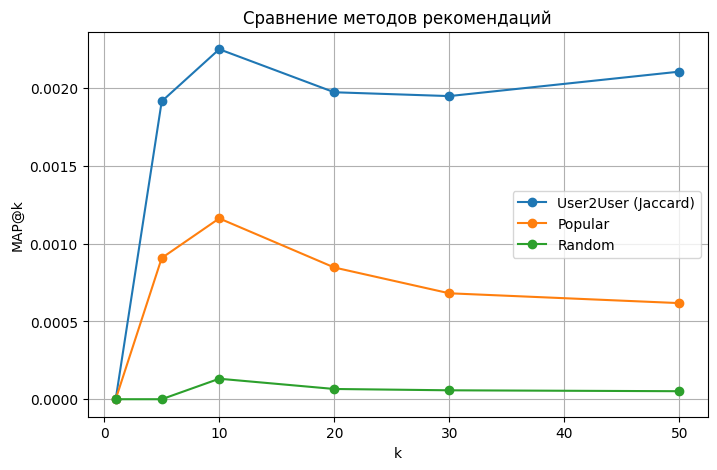

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(ks, user2user_scores, marker='o', label='User2User (Jaccard)')
plt.plot(ks, popular_scores, marker='o', label='Popular')
plt.plot(ks, random_scores, marker='o', label='Random')

plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('Сравнение методов рекомендаций')
plt.legend()
plt.grid(True)
plt.show()

Лучший результат на всех значениях k показал метод User2User на основе меры Жаккара. Однако абсолютные значения MAP@k получились очень маленькими, то есть качество рекомендаций в целом остается низким, метрика колеблется около 0.002. Персонализированный подход лучше рекомендаций популярных и случайных треков, но сама модель пока работает довольно слабо.

Матрица оценок получается очень разреженной, а мы работали с ней как с обычной — это не дело. Перепишем код так, чтобы все методы могли работать с разреженными матрицами, и сравним скорость работы такого подхода с оригинальным.

In [57]:
def jaccard_sparse(ratings: scs.csr_matrix, user_vector: scs.csr_matrix) -> np.array:
    intersection = ratings.dot(user_vector.T).toarray().ravel()
    union = ratings.getnnz(axis=1) + user_vector.getnnz() - intersection

    similarities = np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0
    )
    return similarities


class SparseBaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        data = np.ones(len(self.ratings), dtype=np.float32)
        rows = self.ratings['userId'].values
        cols = self.ratings['trackId'].values

        self.R = scs.csr_matrix((data, (rows, cols)), shape=(self.n_users, self.n_items))

    def recommend(self, uid: int):
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        new_preds = np.zeros((len(preds), k), dtype=int)

        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        for uid in range(self.n_users):
            test_preds.append(self.recommend(uid))

        test_preds = np.array(test_preds)
        test_preds = self.remove_train_items(test_preds, k)

        return test_preds[test_users]


class SparseUser2User(SparseBaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard_sparse
        self.alpha = 0.02

    def similarity(self, user_vector: scs.csr_matrix):
        similarities = self.similarity_func(self.R, user_vector)
        similarities[similarities <= self.alpha] = 0.0
        return similarities

    def recommend(self, uid: int):
        user_vector = self.R.getrow(uid)
        similarities = self.similarity(user_vector)
        similarities[uid] = 0.0

        denom = np.abs(similarities).sum()
        if denom == 0:
            scores = np.zeros(self.n_items)
        else:
            scores = self.R.T.dot(similarities) / denom
            scores = np.asarray(scores).ravel()

        return np.argsort(-scores)

In [58]:
import time

k = 20

start = time.perf_counter()
dense_model = User2User(train_ratings)
dense_preds = dense_model.get_test_recommendations(k=k)
dense_time = time.perf_counter() - start

start = time.perf_counter()
sparse_model = SparseUser2User(train_ratings)
sparse_preds = sparse_model.get_test_recommendations(k=k)
sparse_time = time.perf_counter() - start

print(f"Dense time:  {dense_time:.4f} sec")
print(f"Sparse time: {sparse_time:.4f} sec")
print(f"Speedup:     {dense_time / sparse_time:.2f}x")

print("Dense MAP@20  =", mapk(test_relevant, dense_preds.tolist(), k=20))
print("Sparse MAP@20 =", mapk(test_relevant, sparse_preds.tolist(), k=20))

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Dense time:  31.6680 sec
Sparse time: 0.9222 sec
Speedup:     34.34x
Dense MAP@20  = 0.001973246194773103
Sparse MAP@20 = 0.001973246194773103


/tmp/ipykernel_1357/3177942438.py:34: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


sparse-реализация показала такое же качество рекомендаций (MAP@20 = 0.001973), как и dense-версия, но работает примерно в 35 раз быстрее (27.54 с против 0.78 с). Значит, для разреженной матрицы взаимодействий использование csr_matrix гораздо эффективнее, поскольку оно позволяет сохранить качество модели и существенно ускорить вычисления.

Посмотрим глазами, насколько хорошо модель рекомендует треки — сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя.

In [60]:
model = User2User(train_ratings)

user_id = np.random.randint(0, model.n_users)

In [61]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
70,Your Heart Is As Black As Night,['Melody Gardot']
258,What A Wonderful World,['Louis Armstrong']
639,The Shadow Of Your Smile,['Engelbert Humperdinck']
854,Hello Brother,"['Louis Armstrong', 'His All-Stars']"
858,Fuel,['Metallica']
1354,"Hold On, I'm Comin'",['Sam & Dave']
1456,I Say A Little Prayer,['Aretha Franklin']
1485,Oogway Ascends,"['Hans Zimmer', 'John Powell']"
2199,Secrets,['OneRepublic']
2481,Gangsta's Paradise,"['Coolio', 'L.V.']"


In [62]:
preds = model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Predicted tracks:


,name,artists
40209,Выхода нет,['Сплин']
28651,"Хали-гали, паратрупер",['Леприконсы']
44523,По ресторанам,['Руслан Набиев']
44544,Про красивую жизнь,"[""БАНД'ЭРОС""]"
38144,Попрошу тебя,['Вирус']
234,Wind Of Change,['Scorpions']
1407,Angels (Love Is The Answer),['Morandi']
10667,Плакала берёза,['Корни']
28831,Ром,['Король и Шут']
25906,Дорога в облака,['Браво']


In [65]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
52764,Simon Says,['Pharoahe Monch']
53260,No Scrubs,"['Unlike Pluto', 'Joanna Jones']"
54736,Beat Of My Heart,"['Lost Frequencies', 'Love Harder']"
55255,Follow God,['Kanye West']
56009,I Just Wanna Shine,['Fitz & The Tantrums']
56431,Warriors,"['League of Legends', '2WEI', 'Edda Hayes']"
56515,Река,"['Alexey Krivdin', 'pavluchenko']"
56709,Now We Are Free,"['Andres Newman', 'Abigail', 'Hans Zimmer']"
57438,No Time To Die,['Billie Eilish']
58764,Плачу на техно,"['Cream Soda', 'ХЛЕБ']"


### Модель со скрытыми переменными: ALS

Попробуем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно.

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметим, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS — ниже мы также его реализуем.

На лекции рассматривались два подхода к оптимизации параметров: можно это делать обычным стохастическим градиентным спуском, а можно по очереди обновлять матрицы $P, Q$ — тогда получится метод Alternating Least Squares (ALS). Выведем формулы обновления параметров для обоих методов.

**SGD:**
Для одного наблюдения $(u, i)$ функционал имеет вид
$$L_{ui} = (p_u^{\top} q_i - r_{ui})^2 + \lambda \left(\|p_u\|^2 + \|q_i\|^2\right)$$

Ошибка
$e_{ui} = p_u^{\top} q_i - r_{ui}$

Тогда градиенты по параметрам:
$$
\frac{\partial L_{ui}}{\partial p_u} = 2 e_{ui} q_i + 2 \lambda p_u, \\
\frac{\partial L_{ui}}{\partial q_i} = 2 e_{ui} p_u + 2 \lambda q_i.
$$

Шаги SGD:
$$p_u \leftarrow p_u - \eta \left(2 e_{ui} q_i + 2 \lambda p_u\right),
\\
q_i \leftarrow q_i - \eta \left(2 e_{ui} p_u + 2 \lambda q_i\right)$$

Эквивалентно, если поглотить константу 2 в шаг обучения:
$$p_u \leftarrow p_u - \eta \left((p_u^{\top} q_i - r_{ui}) q_i + \lambda p_u\right),
\\
q_i \leftarrow q_i - \eta \left((p_u^{\top} q_i - r_{ui}) p_u + \lambda q_i\right)$$



**ALS:**

Зафиксируем матрицу $Q$ и будем оптимизировать по $P$. Для пользователя $u$ решается задача
$$L_u = \sum_{i \in I_u} (p_u^{\top} q_i - r_{ui})^2 + \lambda \|p_u\|^2$$

Обозначим через $Q_u \in \mathbb{R}^{|I_u| \times d}$ матрицу латентных векторов объектов, с которыми взаимодействовал пользователь $u$, а через
$r_u$ вектор соответствующих оценок. Тогда
$$L_u = \|Q_u p_u - r_u\|^2 + \lambda \|p_u\|^2$$

Приравнивая градиент к нулю, получаем $Q_u^{\top}(Q_u p_u - r_u) + \lambda p_u = 0$, откуда
$$
(Q_u^{\top} Q_u + \lambda I) p_u = Q_u^{\top} r_u,
\implies
p_u = (Q_u^{\top} Q_u + \lambda I)^{-1} Q_u^{\top} r_u.
$$

Аналогично, при фикс матрице $P$, для объекта $i$:
$$
q_i = (P_i^{\top} P_i + \lambda I)^{-1} P_i^{\top} r_i,
$$
где $P_i$ - матрица латентных векторов пользователей, взаимодействовавших с объектом $i$, а $r_i$ - вектор их оценок.

Итого ALS:
$$
p_u \leftarrow (Q_u^{\top} Q_u + \lambda I)^{-1} Q_u^{\top} r_u,
$$
$$
q_i \leftarrow (P_i^{\top} P_i + \lambda I)^{-1} P_i^{\top} r_i.
$$


Реализуем методы оптимизации параметров для обоих алгоритмов.

In [67]:
class LatentFactorModel(BaseModel):
    def __init__(
        self,
        ratings,
        dim=128,
        mode='sgd',
        lr=0.003,
        lamb=0.01,
        init_scale=0.05,
        seed=42
    ):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.lr = lr
        self.lamb = lamb

        rng = np.random.default_rng(seed)
        self.P = rng.normal(0, init_scale, size=(self.n_users, dim))
        self.Q = rng.normal(0, init_scale, size=(self.n_items, dim))

    def fit(self, num_iters=5):
        user_ids = self.ratings['userId'].to_numpy()
        item_ids = self.ratings['trackId'].to_numpy()
        eye = np.eye(self.dim)

        for epoch in tqdm(range(num_iters)):
            if self.mode == 'sgd':
                order = np.random.permutation(len(self.ratings))

                for idx in order:
                    u = user_ids[idx]
                    i = item_ids[idx]

                    pu = self.P[u].copy()
                    qi = self.Q[i].copy()

                    err = pu @ qi - 1.0

                    self.P[u] -= self.lr * (err * qi + self.lamb * pu)
                    self.Q[i] -= self.lr * (err * pu + self.lamb * qi)

            elif self.mode == 'als':
                for user_id, user_data in self.ratings.groupby('userId'):
                    item_idx = user_data['trackId'].values
                    Q_u = self.Q[item_idx]

                    A = Q_u.T @ Q_u + self.lamb * eye
                    b = Q_u.sum(axis=0)
                    self.P[user_id] = np.linalg.solve(A, b)

                for item_id, item_data in self.ratings.groupby('trackId'):
                    user_idx = item_data['userId'].values
                    P_i = self.P[user_idx]

                    A = P_i.T @ P_i + self.lamb * eye
                    b = P_i.sum(axis=0)
                    self.Q[item_id] = np.linalg.solve(A, b)

    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T
        return np.argsort(pred_rating)[::-1]

    def observed_mse(self):
        user_ids = self.ratings['userId'].to_numpy()
        item_ids = self.ratings['trackId'].to_numpy()

        preds = np.sum(self.P[user_ids] * self.Q[item_ids], axis=1)
        return np.mean((preds - 1.0) ** 2)

Для обоих алгоритмов подберем оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$, посмотрим, как изменяется качество предсказаний с числом итераций обучения. Построим соответствующие графики, сравним со случайным подходом и User2User и сделаем выводы о том, какой алгоритм оказался более подходящим для этой задачи.

Методу SGD свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете.

In [68]:
def evaluate_model(model, ks):
    max_k = max(ks)
    preds = model.get_test_recommendations(k=max_k).tolist()
    scores = {k: mapk(test_relevant, preds, k=k) for k in ks}
    return scores, preds


def grid_search_lfm(mode, dims, ks, num_iters, **model_kwargs):
    results = []

    for dim in dims:
        model = LatentFactorModel(
            train_ratings,
            dim=dim,
            mode=mode,
            **model_kwargs
        )
        model.fit(num_iters=num_iters)

        scores, _ = evaluate_model(model, ks)

        for k in ks:
            results.append({
                'mode': mode,
                'dim': dim,
                'k': k,
                'num_iters': num_iters,
                'MAP@k': scores[k]
            })

    return pd.DataFrame(results).sort_values('MAP@k', ascending=False).reset_index(drop=True)


def learning_curve(mode, dim, k, num_iters, **model_kwargs):
    model = LatentFactorModel(
        train_ratings,
        dim=dim,
        mode=mode,
        **model_kwargs
    )

    history = []

    for epoch in range(1, num_iters + 1):
        model.fit(num_iters=1)
        preds = model.get_test_recommendations(k=k).tolist()
        score = mapk(test_relevant, preds, k=k)

        history.append({
            'epoch': epoch,
            'MAP': score,
            'MSE': model.observed_mse()
        })

    return pd.DataFrame(history), model

In [69]:
ks = [5, 10, 20, 50]

random_model = RandomModel(train_ratings, seed=42)
user2user_model = User2User(train_ratings)

random_scores, _ = evaluate_model(random_model, ks)
u2u_scores, _ = evaluate_model(user2user_model, ks)

baseline_df = pd.DataFrame({
    'k': ks,
    'Random': [random_scores[k] for k in ks],
    'User2User': [u2u_scores[k] for k in ks]
})

baseline_df

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


,k,Random,User2User
0,5,0.000000,0.001915
1,10,0.000132,0.002250
2,20,0.000066,0.001973
3,50,0.000051,0.002106


In [70]:
dims = [16, 32, 64]
ks = [5, 10, 20, 50]

sgd_results = grid_search_lfm(
    mode='sgd',
    dims=dims,
    ks=ks,
    num_iters=10,
    lr=0.01,
    lamb=0.05,
    init_scale=0.05,
    seed=42
)

sgd_results.head(10)

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,mode,dim,k,num_iters,MAP@k
0,sgd,16,10,10,0.001482
1,sgd,16,5,10,0.001319
2,sgd,32,10,10,0.001054
3,sgd,32,20,10,0.000909
4,sgd,64,5,10,0.000894
5,sgd,16,20,10,0.000855
6,sgd,32,50,10,0.000680
7,sgd,64,10,10,0.000667
8,sgd,16,50,10,0.000635
9,sgd,64,20,10,0.000573


In [71]:
als_results = grid_search_lfm(
    mode='als',
    dims=dims,
    ks=ks,
    num_iters=8,
    lamb=0.1,
    init_scale=0.05,
    seed=42
)

als_results.head(10)

  0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

,mode,dim,k,num_iters,MAP@k
0,als,64,5,8,0.003546
1,als,32,5,8,0.002482
2,als,64,10,8,0.002051
3,als,32,10,8,0.001426
4,als,16,5,8,0.001348
5,als,64,20,8,0.001202
6,als,16,10,8,0.000912
7,als,64,50,8,0.000861
8,als,32,20,8,0.000779
9,als,32,50,8,0.000610


In [72]:
best_sgd = sgd_results.iloc[0]
best_als = als_results.iloc[0]

print("Best SGD:")
print(best_sgd)
print()

print("Best ALS:")
print(best_als)

Best SGD:
mode              sgd
dim                16
k                  10
num_iters          10
MAP@k        0.001482
Name: 0, dtype: object

Best ALS:
mode              als
dim                64
k                   5
num_iters           8
MAP@k        0.003546
Name: 0, dtype: object


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


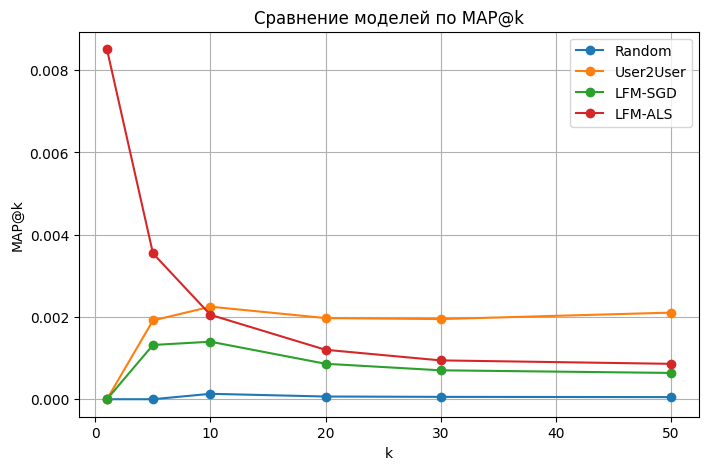

In [73]:
ks_plot = [1, 5, 10, 20, 30, 50]

best_sgd_model = LatentFactorModel(
    train_ratings,
    dim=int(best_sgd['dim']),
    mode='sgd',
    lr=0.01,
    lamb=0.05,
    init_scale=0.05,
    seed=42
)
best_sgd_model.fit(num_iters=int(best_sgd['num_iters']))

best_als_model = LatentFactorModel(
    train_ratings,
    dim=int(best_als['dim']),
    mode='als',
    lamb=0.1,
    init_scale=0.05,
    seed=42
)
best_als_model.fit(num_iters=int(best_als['num_iters']))

random_scores_plot, _ = evaluate_model(random_model, ks_plot)
u2u_scores_plot, _ = evaluate_model(user2user_model, ks_plot)
sgd_scores_plot, _ = evaluate_model(best_sgd_model, ks_plot)
als_scores_plot, _ = evaluate_model(best_als_model, ks_plot)

plt.figure(figsize=(8, 5))
plt.plot(ks_plot, [random_scores_plot[k] for k in ks_plot], marker='o', label='Random')
plt.plot(ks_plot, [u2u_scores_plot[k] for k in ks_plot], marker='o', label='User2User')
plt.plot(ks_plot, [sgd_scores_plot[k] for k in ks_plot], marker='o', label='LFM-SGD')
plt.plot(ks_plot, [als_scores_plot[k] for k in ks_plot], marker='o', label='LFM-ALS')

plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('Сравнение моделей по MAP@k')
plt.grid(True)
plt.legend()
plt.show()

In [74]:
curve_k = 20

sgd_curve, sgd_curve_model = learning_curve(
    mode='sgd',
    dim=int(best_sgd['dim']),
    k=curve_k,
    num_iters=15,
    lr=0.01,
    lamb=0.05,
    init_scale=0.05,
    seed=42
)

als_curve, als_curve_model = learning_curve(
    mode='als',
    dim=int(best_als['dim']),
    k=curve_k,
    num_iters=10,
    lamb=0.1,
    init_scale=0.05,
    seed=42
)

display(sgd_curve.head())
display(als_curve.head())

  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

,epoch,MAP,MSE
0,1,0.000027,0.999036
1,2,0.000039,0.998311
2,3,0.000024,0.997534
3,4,0.000019,0.996439
4,5,0.000012,0.994693


,epoch,MAP,MSE
0,1,0.000482,0.000070
1,2,0.000499,0.000063
2,3,0.000559,0.000058
3,4,0.000627,0.000055
4,5,0.000696,0.000051


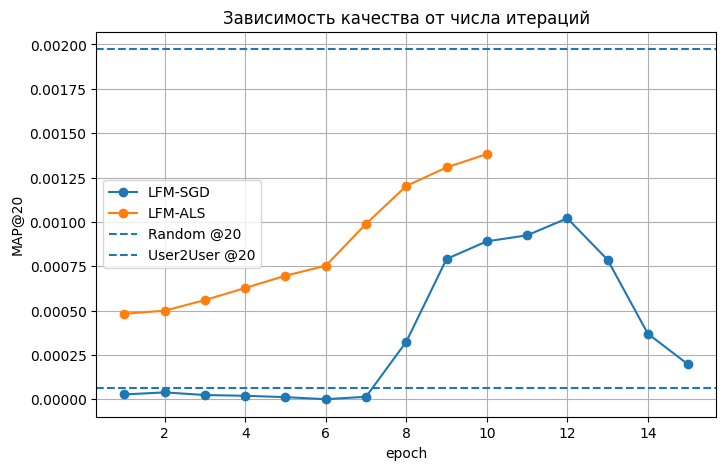

In [75]:
random_map20 = random_scores_plot[20]
u2u_map20 = u2u_scores_plot[20]

plt.figure(figsize=(8, 5))
plt.plot(sgd_curve['epoch'], sgd_curve['MAP'], marker='o', label='LFM-SGD')
plt.plot(als_curve['epoch'], als_curve['MAP'], marker='o', label='LFM-ALS')

plt.axhline(random_map20, linestyle='--', label='Random @20')
plt.axhline(u2u_map20, linestyle='--', label='User2User @20')

plt.xlabel('epoch')
plt.ylabel('MAP@20')
plt.title('Зависимость качества от числа итераций')
plt.grid(True)
plt.legend()
plt.show()

Видим, что для SGD качество рекомендаций остается низким и не растет с увеличением числа эпох: несмотря на постепенное уменьшение MSE, значение MAP колеблется около нуля. Это показывает, что оптимизация ошибки на наблюдаемых взаимодействиях не приводит к улучшению качества ранжирования, и модель фактически не учится хорошо рекомендовать треки.

ALS оказался лучшим методом: он показал качество выше, чем User2User (0.003546 против 0.001915 при k = 5)

При оптимизации параметров матрицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степень обученности модели вручную.

In [77]:
model = best_als_model

In [78]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = model.Q @ model.Q[example_trackId]
preds = preds / np.sqrt((model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

In [79]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
2058,Последний герой,['КИНО'],0.747996
5570,Моё сердце,['Сплин'],0.689196
16192,Однажды мир прогнётся под нас,['Машина времени'],0.670900
17811,На заре,['Альянс'],0.670324
2179,Восьмиклассница,['КИНО'],0.652000
17331,"Последнее письмо (Гудбай, Америка)",['Nautilus Pompilius'],0.636879
16637,Zodiac,['Zodiac'],0.635969
9689,Bicycle Race,['Queen'],0.635969
5153,Stormbringer,['Deep Purple'],0.635969


Построим также модель iALS и сравним ее качество с обучением ALS и SGD.

In [81]:
class iALSModel(SparseBaseModel):
    def __init__(self, ratings, dim=64, alpha=40.0, lamb=0.1, seed=42):
        super().__init__(ratings)

        self.dim = dim
        self.alpha = alpha
        self.lamb = lamb

        rng = np.random.default_rng(seed)
        self.P = 0.01 * rng.standard_normal((self.n_users, dim))
        self.Q = 0.01 * rng.standard_normal((self.n_items, dim))

        self.R_csc = self.R.tocsc()

    def fit(self, num_iters=10):
        I = np.eye(self.dim)

        for _ in tqdm(range(num_iters)):
            QtQ = self.Q.T @ self.Q
            for u in range(self.n_users):
                item_idx = self.R[u].indices
                if len(item_idx) == 0:
                    continue

                Q_u = self.Q[item_idx]
                A = QtQ + self.alpha * (Q_u.T @ Q_u) + self.lamb * I
                b = (1.0 + self.alpha) * Q_u.sum(axis=0)

                self.P[u] = np.linalg.solve(A, b)

            PtP = self.P.T @ self.P
            for i in range(self.n_items):
                user_idx = self.R_csc[:, i].indices
                if len(user_idx) == 0:
                    continue

                P_i = self.P[user_idx]
                A = PtP + self.alpha * (P_i.T @ P_i) + self.lamb * I
                b = (1.0 + self.alpha) * P_i.sum(axis=0)

                self.Q[i] = np.linalg.solve(A, b)

    def recommend(self, uid):
        scores = self.P[uid] @ self.Q.T
        return np.argsort(scores)[::-1]

In [82]:
ks = [5, 10, 20]

sgd_model = LatentFactorModel(
    train_ratings,
    dim=16,
    mode='sgd',
    lr=0.01,
    lamb=0.05,
    init_scale=0.05,
    seed=42
)
sgd_model.fit(num_iters=10)

als_model = LatentFactorModel(
    train_ratings,
    dim=64,
    mode='als',
    lamb=0.1,
    init_scale=0.05,
    seed=42
)
als_model.fit(num_iters=8)

ials_model = iALSModel(
    train_ratings,
    dim=64,
    alpha=40.0,
    lamb=0.1,
    seed=42
)
ials_model.fit(num_iters=10)

def eval_scores(model, ks):
    preds = model.get_test_recommendations(k=max(ks)).tolist()
    return [mapk(test_relevant, preds, k=k) for k in ks]

comparison = pd.DataFrame({
    'k': ks,
    'SGD': eval_scores(sgd_model, ks),
    'ALS': eval_scores(als_model, ks),
    'iALS': eval_scores(ials_model, ks),
})

comparison

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]
/tmp/ipykernel_1357/3177942438.py:34: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


,k,SGD,ALS,iALS
0,5,0.001390,0.003546,0.003574
1,10,0.001426,0.002051,0.002194
2,20,0.000875,0.001202,0.001551


Лучшее качество среди всех моделей показал iALS: он минимально обошел обычный ALS на всех рассмотренных k и заметно обошел SGD.

### Второй уровень рекомендаций

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

Для каждого пользователя возьмем топ-100 рекомендованных треков от модели LFM (ALS) и топ-100 от модели User2User — это будут наши кандидаты, которые мы затем будем ранжировать бустингом.

In [83]:
lfm_model = best_als_model
u2u_model = user2user_model

lfm_top100 = lfm_model.get_test_recommendations(k=100)
u2u_top100 = u2u_model.get_test_recommendations(k=100)

candidates = []
for i, user_id in enumerate(test_users):
    cand = np.unique(np.concatenate([lfm_top100[i], u2u_top100[i]]))
    candidates.append(cand)

candidate_df = pd.DataFrame({
    'userId': test_users,
    'candidates': candidates,
    'n_candidates': [len(c) for c in candidates]
})

candidate_tracks = pd.DataFrame({
    'userId': np.repeat(test_users, [len(c) for c in candidates]),
    'trackId': np.concatenate(candidates)
})

candidate_df.head(), candidate_tracks.head()

/tmp/ipykernel_1357/3963541033.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


(   userId                                         candidates  n_candidates
 0       0  [23, 33, 62, 94, 189, 218, 388, 418, 419, 421,...           186
 1       1  [81, 97, 177, 220, 234, 409, 805, 809, 816, 10...           179
 2       2  [164, 354, 421, 422, 464, 630, 707, 710, 754, ...           170
 3       3  [97, 164, 177, 220, 300, 377, 409, 805, 816, 1...           187
 4       4  [46, 418, 805, 886, 1019, 1056, 1286, 1597, 16...           186,
    userId  trackId
 0       0       23
 1       0       33
 2       0       62
 3       0       94
 4       0      189)

Подготовим датасет для обучения модели ранжирования. Он состоит из пар: объект, целевая переменная. Объект — это пара (user, item) и дополнительные признаки на их основе:
 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из User2User модели
 1) доля пользователей, слушавших этот трек (взять из обучающей выборки в Части 1)
 1) количество прослушанных пользователем треков (взять из обучающей выборки в Части 1)

В качестве целевой переменной возьмем бинарную метку "попал ли трек в 50 последних прослушанных пользователем".

Разобьем полученную выборку на обучающую и тестовую в отношении 3:2 так, чтобы пропорции положительных и отрицательных примеров в обоих подвыборках были одинаковыми.

In [85]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [86]:
from sklearn.model_selection import train_test_split
import catboost

rank_df = candidate_tracks.copy()

train_user_counts = train_ratings.groupby('userId')['trackId'].nunique()
track_popularity = train_ratings.groupby('trackId')['userId'].nunique() / train_ratings['userId'].nunique()

test_rel_sets = {
    user_id: set(user_data['trackId'].tolist())
    for user_id, user_data in test_ratings.groupby('userId')
}

R_u2u = u2u_model.R
mean_jaccard = np.zeros(u2u_model.n_users)

for uid in range(u2u_model.n_users):
    sims = jaccard(R_u2u, R_u2u[uid])
    sims[uid] = 0.0
    mean_jaccard[uid] = sims.mean()

P = lfm_model.P
Q = lfm_model.Q

user_norms = np.linalg.norm(P, axis=1)
item_norms = np.linalg.norm(Q, axis=1)

uids = rank_df['userId'].to_numpy()
iids = rank_df['trackId'].to_numpy()

cos_sim = np.sum(P[uids] * Q[iids], axis=1) / (user_norms[uids] * item_norms[iids] + 1e-8)
cos_dist = 1.0 - cos_sim

rank_df['lfm_cosine_distance'] = cos_dist
rank_df['mean_jaccard'] = rank_df['userId'].map(lambda u: mean_jaccard[u])
rank_df['track_popularity'] = rank_df['trackId'].map(track_popularity).fillna(0.0)
rank_df['user_track_count'] = rank_df['userId'].map(train_user_counts).fillna(0).astype(int)

rank_df['target'] = [
    int(track_id in test_rel_sets.get(user_id, set()))
    for user_id, track_id in zip(rank_df['userId'], rank_df['trackId'])
]

train_df, test_df = train_test_split(
    rank_df,
    test_size=0.4,
    random_state=42,
    stratify=rank_df['target']
)

train_df = train_df.sort_values('userId').reset_index(drop=True)
test_df = test_df.sort_values('userId').reset_index(drop=True)

feature_cols = [
    'userId',
    'trackId',
    'lfm_cosine_distance',
    'mean_jaccard',
    'track_popularity',
    'user_track_count'
]

X_train = train_df[feature_cols]
y_train = train_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']

train_group_id = train_df['userId'].to_numpy()
test_group_id = test_df['userId'].to_numpy()

train_pool = catboost.Pool(
    X_train,
    y_train,
    group_id=train_group_id,
    cat_features=[0, 1]
)

test_pool = catboost.Pool(
    X_test,
    y_test,
    group_id=test_group_id,
    cat_features=[0, 1]
)

print("train size:", X_train.shape, "positive rate:", y_train.mean())
print("test size: ", X_test.shape, "positive rate:", y_test.mean())
rank_df.head()

train size: (26443, 6) positive rate: 0.005180955262262224
test size:  (17629, 6) positive rate: 0.005218673776164274


,userId,trackId,lfm_cosine_distance,mean_jaccard,track_popularity,user_track_count,target
0,0,23,0.668785,0.003435,0.037344,206,0
1,0,33,0.625062,0.003435,0.033195,206,0
2,0,62,0.698397,0.003435,0.045643,206,0
3,0,94,0.712017,0.003435,0.029046,206,0
4,0,189,0.746187,0.003435,0.045643,206,0


Как уже было сказано, для построения ранжирующей модели мы будем пользоваться библиотекой [CatBoost](https://www.youtube.com/watch?v=X1-MXdyThJ0).

Для преобразования датасета в удобный вид полезно использовать метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

Обучим `CatBoostClassifier`, сделаем с его помощью предсказания для тестовой выборки и посчитаем MAP@20. Сравним с рекомендациями моделей User2User и LFM — для честного сравнения пересчитаем предсказания моделей на новой тестовой выборке.

In [88]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=50
)

cb_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

test_df_eval = test_df.copy()
test_df_eval['cb_score'] = cb_model.predict_proba(X_test)[:, 1]

P = lfm_model.P
Q = lfm_model.Q
test_df_eval['lfm_score'] = np.sum(
    P[test_df_eval['userId'].values] * Q[test_df_eval['trackId'].values],
    axis=1
)

u2u_scores_all = u2u_model.R @ u2u_model.R.T
u2u_item_scores = []
for uid in test_df_eval['userId'].unique():
    user_vector = u2u_model.R[uid]
    sims = u2u_model.similarity(user_vector)
    sims[uid] = 0.0
    denom = np.abs(sims).sum()
    if denom == 0:
        scores = np.zeros(u2u_model.n_items)
    else:
        scores = sims @ u2u_model.R / denom

    mask = test_df_eval['userId'] == uid
    item_ids = test_df_eval.loc[mask, 'trackId'].values
    u2u_item_scores.extend(scores[item_ids])

test_df_eval['u2u_score'] = u2u_item_scores

def mapk_from_grouped_df(df, score_col, k=20):
    relevant = []
    predicted = []

    for user_id, group in df.groupby('userId'):
        rel = group.loc[group['target'] == 1, 'trackId'].tolist()

        if len(rel) == 0:
            continue

        pred = group.sort_values(score_col, ascending=False)['trackId'].tolist()

        relevant.append(rel)
        predicted.append(pred)

    return mapk(relevant, predicted, k=k)

cb_map20 = mapk_from_grouped_df(test_df_eval, 'cb_score', k=20)
lfm_map20 = mapk_from_grouped_df(test_df_eval, 'lfm_score', k=20)
u2u_map20 = mapk_from_grouped_df(test_df_eval, 'u2u_score', k=20)

comparison_lvl2 = pd.DataFrame({
    'model': ['CatBoostClassifier', 'LFM', 'User2User'],
    'MAP@20': [cb_map20, lfm_map20, u2u_map20]
}).sort_values('MAP@20', ascending=False).reset_index(drop=True)

comparison_lvl2

0:	test: 0.5875757	best: 0.5875757 (0)	total: 71.5ms	remaining: 21.4s
50:	test: 0.7159865	best: 0.7159865 (50)	total: 2.53s	remaining: 12.3s
100:	test: 0.7274390	best: 0.7322630 (97)	total: 5.46s	remaining: 10.8s
150:	test: 0.7352514	best: 0.7372713 (134)	total: 7.03s	remaining: 6.94s
200:	test: 0.7350605	best: 0.7372713 (134)	total: 8.58s	remaining: 4.23s
250:	test: 0.7322112	best: 0.7372713 (134)	total: 10.2s	remaining: 1.99s
299:	test: 0.7295857	best: 0.7372713 (134)	total: 11.7s	remaining: 0us

bestTest = 0.737271322
bestIteration = 134

Shrink model to first 135 iterations.


,model,MAP@20
0,CatBoostClassifier,0.162241
1,User2User,0.064329
2,LFM,0.044546


CatBoostClassifier сильно улучшил качество рекомендаций по сравнению с моделями первого уровня. На новой тестовой выборке он показал MAP@20 = 0.162241, что заметно выше, чем у User2User (0.064329) и LFM (0.044546).
Двухуровневый подход оказался эффективным, быстрые модели первого уровня хорошо подходят для отбора кандидатов, а CatBoost уже качественно ранжирует их с использованием дополнительных признаков.

Обучим `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделаем все те же действия, что и с `CatBoostClassifier`, и сравним результаты.

In [89]:
from catboost import CatBoostRanker

ranker = CatBoostRanker(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='YetiRank',
    eval_metric='MAP:top=20',
    random_seed=42,
    verbose=50
)

ranker.fit(train_pool, eval_set=test_pool, use_best_model=True)

test_rank_df = test_df.copy()
test_rank_df['ranker_score'] = ranker.predict(test_pool)

ranker_map20 = mapk_from_grouped_df(test_rank_df, 'ranker_score', k=20)

comparison_rank = pd.DataFrame({
    'model': ['CatBoostRanker', 'CatBoostClassifier', 'User2User', 'LFM'],
    'MAP@20': [ranker_map20, cb_map20, u2u_map20, lfm_map20]
}).sort_values('MAP@20', ascending=False).reset_index(drop=True)

comparison_rank

Groupwise loss function. OneHotMaxSize set to 10
0:	learn: 0.0238637	test: 0.0118253	best: 0.0118253 (0)	total: 240ms	remaining: 1m 11s
50:	learn: 0.1275926	test: 0.0337020	best: 0.0337020 (50)	total: 11.7s	remaining: 57.4s
100:	learn: 0.1734862	test: 0.0350008	best: 0.0358538 (87)	total: 17.1s	remaining: 33.7s
150:	learn: 0.2167427	test: 0.0345203	best: 0.0358538 (87)	total: 23.3s	remaining: 23s
200:	learn: 0.2421945	test: 0.0322161	best: 0.0358538 (87)	total: 28.4s	remaining: 14s
250:	learn: 0.2628658	test: 0.0311282	best: 0.0358538 (87)	total: 35s	remaining: 6.83s
299:	learn: 0.2731026	test: 0.0300526	best: 0.0358538 (87)	total: 40.1s	remaining: 0us

bestTest = 0.03585375449
bestIteration = 87

Shrink model to first 88 iterations.


,model,MAP@20
0,CatBoostClassifier,0.162241
1,CatBoostRanker,0.148794
2,User2User,0.064329
3,LFM,0.044546


CatBoostRanker улучшил качество по сравнению с моделями первого уровня и значительно превзошел User2User и LFM, однако оказался немного хуже CatBoostClassifier. CatBoostRanker показал MAP@20 = 0.1487, а CatBoostClassifier дал лучший результат - 0.1622.